# 14. Fama-French 五因子模型

## 学习目标

- 理解五因子模型相比三因子模型的改进动机
- 掌握 **RMW（盈利因子）** 和 **CMA（投资因子）** 的构建方法
- 能够用 Python 实现完整的五因子回归
- 学会对比三因子和五因子的解释力差异（调整 R²）
- 不做机械调包，理解每个因子背后的经济学故事

## 环境依赖

```bash
pip install numpy pandas matplotlib scipy statsmodels
```

## 一、理论基础：为什么需要五因子？

### 1.1 三因子模型的局限

Fama-French 1993 年提出的三因子模型（市场、规模、价值）解释了很多股票收益的横截面差异，但后续研究发现了新的异象（anomalies）：

- **盈利效应**：高盈利公司的股票收益显著高于低盈利公司
- **投资效应**：保守投资（低资产增长）的公司收益高于激进投资的公司

这些效应无法被三因子模型中的 SMB 和 HML 完全解释。

### 1.2 五因子模型公式

2015 年，Fama 和 French 在三因子基础上增加了两个新因子：

$$R_i - R_f = \alpha_i + \beta_i(R_m - R_f) + s_i \cdot SMB + h_i \cdot HML + r_i \cdot RMW + c_i \cdot CMA + \epsilon_i$$

新增的两个因子：

| 因子 | 全称 | 含义 | 经济解释 |
|------|------|------|----------|
| $RMW$ | Robust Minus Weak | 盈利因子 | 高盈利公司 - 低盈利公司 的收益差 |
| $CMA$ | Conservative Minus Aggressive | 投资因子 | 保守投资公司 - 激进投资公司 的收益差 |

### 1.3 五个因子的完整图谱

| 因子 | 符号 | 构建方式 | 捕获的风险/异象 |
|------|------|----------|------------------|
| 市场因子 | $R_m - R_f$ | 市场组合收益 - 无风险利率 | 系统性风险 |
| 规模因子 | $SMB$ | 小市值 - 大市值 | 规模效应 |
| 价值因子 | $HML$ | 高 B/M - 低 B/M | 价值效应 |
| 盈利因子 | $RMW$ | 高盈利 - 低盈利 | 盈利质量溢价 |
| 投资因子 | $CMA$ | 低投资 - 高投资 | 保守投资溢价 |

### 1.4 经济学故事：为什么 RMW 和 CMA 有效？

**RMW（盈利因子）** 的经济学逻辑：
- 高盈利公司有更强的现金流创造能力，在经济下行时更抗跌
- 市场对高盈利公司给予了「质量溢价」
- 类似于「质量因子」（Quality Factor）的概念

**CMA（投资因子）** 的经济学逻辑：
- 激进投资（大量资本支出、并购）的公司面临更大的不确定性
- 保守投资的公司往往有更稳定的现金流和更低的财务风险
- 投资者要求更高的回报来补偿激进投资带来的风险

## 二、Python 实现

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print('环境准备完成！')

环境准备完成！


### 2.1 生成模拟数据

我们需要在三因子的基础上，为每只股票额外生成：
- **盈利能力（Profitability）**：用 ROE 近似
- **投资水平（Investment）**：用总资产增长率近似

In [2]:
def generate_five_factor_data(n_stocks=150, n_periods=60):
    """
    生成包含五因子特征的模拟股票数据
    n_stocks: 股票数量
    n_periods: 时间段数量（月）
    """
    np.random.seed(42)
    
    dates = pd.date_range('2019-01-01', periods=n_periods, freq='ME')
    stock_ids = [f'Stock_{i:03d}' for i in range(n_stocks)]
    
    # === 股票特征 ===
    market_caps = np.exp(np.random.normal(10, 2, n_stocks))        # 市值
    bm_ratios = np.random.lognormal(-1, 0.8, n_stocks)            # B/M 比
    bm_ratios = np.clip(bm_ratios, 0.05, 5)
    profitability = np.random.normal(0.08, 0.06, n_stocks)         # 盈利能力 (ROE)
    profitability = np.clip(profitability, -0.15, 0.30)
    investment_rate = np.random.normal(0.10, 0.08, n_stocks)       # 投资率 (资产增长)
    investment_rate = np.clip(investment_rate, -0.10, 0.40)
    
    # === 市场收益 ===
    market_returns = np.random.normal(0.008, 0.05, n_periods)
    
    returns_data = []
    for i in range(n_stocks):
        # 各因子效应
        size_effect = -0.3 * (np.log(market_caps[i]) - 10) / 2
        value_effect = 0.2 * (np.log(bm_ratios[i]) + 1) / 2
        # 新增：盈利效应（高盈利 -> 更高收益）
        profit_effect = 0.4 * (profitability[i] - 0.08) / 0.06
        # 新增：投资效应（低投资 -> 更高收益）
        invest_effect = -0.3 * (investment_rate[i] - 0.10) / 0.08
        
        stock_returns = (
            0.001                                    # alpha
            + 1.0 * market_returns                   # 市场 beta
            + size_effect * 0.015                    # 规模效应
            + value_effect * 0.015                   # 价值效应
            + profit_effect * 0.012                  # 盈利效应
            + invest_effect * 0.010                  # 投资效应
            + np.random.normal(0, 0.025, n_periods)  # 个股噪声
        )
        
        for t in range(n_periods):
            returns_data.append({
                'date': dates[t],
                'stock_id': stock_ids[i],
                'return': stock_returns[t],
                'market_cap': market_caps[i],
                'bm_ratio': bm_ratios[i],
                'profitability': profitability[i],    # 盈利能力
                'investment_rate': investment_rate[i] # 投资率
            })
    
    df = pd.DataFrame(returns_data)
    df['date'] = pd.to_datetime(df['date'])
    return df, market_returns, dates

# 生成数据
df, market_returns, dates = generate_five_factor_data()
print(f"数据维度: {df.shape}")
print(f"时间范围: {df['date'].min()} 到 {df['date'].max()}")
print(f"股票数量: {df['stock_id'].nunique()}")
print(f"\n股票特征统计:")
print(df.groupby('stock_id')[['market_cap', 'bm_ratio', 'profitability', 'investment_rate']].first().describe().round(4))

数据维度: (9000, 7)
时间范围: 2019-01-31 00:00:00 到 2023-12-31 00:00:00
股票数量: 150

股票特征统计:
         market_cap  bm_ratio  profitability  investment_rate
count  1.500000e+02  150.0000       150.0000         150.0000
mean   1.031661e+05    0.5466         0.0833           0.0922
std    3.145681e+05    0.5927         0.0570           0.0777
min    1.168055e+02    0.0500        -0.0474          -0.0977
25%    5.781627e+03    0.2119         0.0440           0.0391
50%    1.978775e+04    0.4122         0.0821           0.0887
75%    5.880995e+04    0.6314         0.1211           0.1429
max    3.037314e+06    5.0000         0.2114           0.3463


### 2.2 构建市场因子（Rm - Rf）

In [3]:
# 无风险利率：3% 年化
rf_annual = 0.03
rf_monthly = rf_annual / 12

# 市场超额收益
market_df = pd.DataFrame({
    'date': dates,
    'Rm': market_returns,
    'Rf': rf_monthly,
    'Rm_Rf': market_returns - rf_monthly
})

print(f"市场超额收益统计:")
print(market_df['Rm_Rf'].describe().round(4))

市场超额收益统计:
count    60.0000
mean      0.0104
std       0.0558
min      -0.1293
25%      -0.0233
50%       0.0072
75%       0.0442
max       0.1342
Name: Rm_Rf, dtype: float64


### 2.3 构建 SMB 因子（规模）

In [4]:
def build_smb_factor(df):
    """
    构建 SMB (Small Minus Big) 因子
    按市值中位数分为小市值和大市值两组
    """
    smb_results = []
    
    for date, group in df.groupby('date'):
        median_cap = group['market_cap'].median()
        
        small_stocks = group[group['market_cap'] <= median_cap]
        big_stocks = group[group['market_cap'] > median_cap]
        
        def weighted_return(sub_df):
            weights = sub_df['market_cap'] / sub_df['market_cap'].sum()
            return (sub_df['return'] * weights).sum()
        
        r_small = weighted_return(small_stocks)
        r_big = weighted_return(big_stocks)
        
        smb_results.append({
            'date': date,
            'SMB': r_small - r_big
        })
    
    return pd.DataFrame(smb_results)

smb_df = build_smb_factor(df)
print(f"SMB 因子均值: {smb_df['SMB'].mean():.4f} ({smb_df['SMB'].mean()*12*100:.2f}% 年化)")

SMB 因子均值: 0.0059 (7.06% 年化)


### 2.4 构建 HML 因子（价值）

In [5]:
def build_hml_factor(df):
    """
    构建 HML (High Minus Low) 因子
    按 B/M 比的 30% 和 70% 分位数分组
    """
    hml_results = []
    
    for date, group in df.groupby('date'):
        q30 = group['bm_ratio'].quantile(0.3)
        q70 = group['bm_ratio'].quantile(0.7)
        
        high_bm = group[group['bm_ratio'] >= q70]
        low_bm = group[group['bm_ratio'] <= q30]
        
        def weighted_return(sub_df):
            weights = sub_df['market_cap'] / sub_df['market_cap'].sum()
            return (sub_df['return'] * weights).sum()
        
        r_high = weighted_return(high_bm)
        r_low = weighted_return(low_bm)
        
        hml_results.append({
            'date': date,
            'HML': r_high - r_low
        })
    
    return pd.DataFrame(hml_results)

hml_df = build_hml_factor(df)
print(f"HML 因子均值: {hml_df['HML'].mean():.4f} ({hml_df['HML'].mean()*12*100:.2f}% 年化)")

HML 因子均值: 0.0028 (3.36% 年化)


### 2.5 构建 RMW 因子（盈利）⭐ 新增

**构建逻辑**：
1. 每期按盈利能力（ROE）的 30%/70% 分位数将股票分为三组
2. **Robust (R)**：盈利能力 ≥ 70% 分位数（高盈利公司）
3. **Weak (W)**：盈利能力 ≤ 30% 分位数（低盈利公司）
4. $RMW = R_{robust} - R_{weak}$

经济学含义：高盈利公司有更强的抗风险能力，投资者愿意为其支付溢价。

In [6]:
def build_rmw_factor(df):
    """
    构建 RMW (Robust Minus Weak) 盈利因子
    按盈利能力的 30%/70% 分位数分组
    高盈利组(Robust) - 低盈利组(Weak)
    """
    rmw_results = []
    
    for date, group in df.groupby('date'):
        q30 = group['profitability'].quantile(0.3)
        q70 = group['profitability'].quantile(0.7)
        
        # Robust：高盈利（>= 70% 分位数）
        robust = group[group['profitability'] >= q70]
        # Weak：低盈利（<= 30% 分位数）
        weak = group[group['profitability'] <= q30]
        
        def weighted_return(sub_df):
            weights = sub_df['market_cap'] / sub_df['market_cap'].sum()
            return (sub_df['return'] * weights).sum()
        
        r_robust = weighted_return(robust)
        r_weak = weighted_return(weak)
        
        rmw_results.append({
            'date': date,
            'RMW': r_robust - r_weak
        })
    
    return pd.DataFrame(rmw_results)

rmw_df = build_rmw_factor(df)
print(f"RMW 因子均值: {rmw_df['RMW'].mean():.4f} ({rmw_df['RMW'].mean()*12*100:.2f}% 年化)")
print(f"RMW 因子标准差: {rmw_df['RMW'].std():.4f}")
print(f"\n解读：RMW > 0 说明高盈利公司的收益高于低盈利公司")

RMW 因子均值: 0.0085 (10.23% 年化)
RMW 因子标准差: 0.0167

解读：RMW > 0 说明高盈利公司的收益高于低盈利公司


### 2.6 构建 CMA 因子（投资）⭐ 新增

**构建逻辑**：
1. 每期按投资率（总资产增长率）的 30%/70% 分位数将股票分为三组
2. **Conservative (C)**：投资率 ≤ 30% 分位数（保守投资公司）
3. **Aggressive (A)**：投资率 ≥ 70% 分位数（激进投资公司）
4. $CMA = R_{conservative} - R_{aggressive}$

经济学含义：激进投资的公司面临更大的不确定性（扩张失败风险），投资者要求更高回报。保守投资的公司现金流更稳定，因此收益反而更高。

**注意**：CMA 的方向是「保守 - 激进」，所以系数 c > 0 表示组合偏向保守投资的公司。

In [7]:
def build_cma_factor(df):
    """
    构建 CMA (Conservative Minus Aggressive) 投资因子
    按投资率的 30%/70% 分位数分组
    保守投资组(Conservative) - 激进投资组(Aggressive)
    """
    cma_results = []
    
    for date, group in df.groupby('date'):
        q30 = group['investment_rate'].quantile(0.3)
        q70 = group['investment_rate'].quantile(0.7)
        
        # Conservative：低投资（<= 30% 分位数，保守投资）
        conservative = group[group['investment_rate'] <= q30]
        # Aggressive：高投资（>= 70% 分位数，激进投资）
        aggressive = group[group['investment_rate'] >= q70]
        
        def weighted_return(sub_df):
            weights = sub_df['market_cap'] / sub_df['market_cap'].sum()
            return (sub_df['return'] * weights).sum()
        
        r_conservative = weighted_return(conservative)
        r_aggressive = weighted_return(aggressive)
        
        cma_results.append({
            'date': date,
            'CMA': r_conservative - r_aggressive
        })
    
    return pd.DataFrame(cma_results)

cma_df = build_cma_factor(df)
print(f"CMA 因子均值: {cma_df['CMA'].mean():.4f} ({cma_df['CMA'].mean()*12*100:.2f}% 年化)")
print(f"CMA 因子标准差: {cma_df['CMA'].std():.4f}")
print(f"\n解读：CMA > 0 说明保守投资公司的收益高于激进投资公司")

CMA 因子均值: 0.0066 (7.93% 年化)
CMA 因子标准差: 0.0150

解读：CMA > 0 说明保守投资公司的收益高于激进投资公司


### 2.7 合并所有因子

In [8]:
# 合并五个因子
factors_df = market_df[['date', 'Rm_Rf']].copy()
factors_df = factors_df.merge(smb_df[['date', 'SMB']], on='date')
factors_df = factors_df.merge(hml_df[['date', 'HML']], on='date')
factors_df = factors_df.merge(rmw_df[['date', 'RMW']], on='date')
factors_df = factors_df.merge(cma_df[['date', 'CMA']], on='date')

print("五因子数据:")
print(factors_df.head())
print(f"\n因子相关系数矩阵:")
corr = factors_df[['Rm_Rf', 'SMB', 'HML', 'RMW', 'CMA']].corr().round(3)
print(corr)

五因子数据:
        date     Rm_Rf       SMB       HML       RMW       CMA
0 2019-01-31  0.043349 -0.003991 -0.010889  0.011063  0.001602
1 2019-02-28 -0.040608 -0.004601 -0.051167  0.031842  0.024485
2 2019-03-31  0.048980  0.003143 -0.007987  0.009849  0.023129
3 2019-04-30  0.073282 -0.002723  0.003866  0.018885  0.002637
4 2019-05-31  0.026172  0.010911  0.033163 -0.028385 -0.010770

因子相关系数矩阵:
       Rm_Rf    SMB    HML    RMW    CMA
Rm_Rf  1.000  0.148  0.268 -0.235  0.112
SMB    0.148  1.000  0.485 -0.454 -0.514
HML    0.268  0.485  1.000 -0.681 -0.247
RMW   -0.235 -0.454 -0.681  1.000  0.397
CMA    0.112 -0.514 -0.247  0.397  1.000


## 三、回归分析：三因子 vs 五因子

### 3.1 构建投资组合

In [9]:
# 构建等权重投资组合
portfolio_df = df.groupby('date')['return'].mean().reset_index()
portfolio_df.columns = ['date', 'R_portfolio']

# 合并因子数据
reg_data = portfolio_df.merge(factors_df, on='date')
reg_data['R_p_Rf'] = reg_data['R_portfolio'] - rf_monthly

print(f"回归数据维度: {reg_data.shape}")
print(reg_data.head())

回归数据维度: (60, 8)
        date  R_portfolio     Rm_Rf       SMB       HML       RMW       CMA  \
0 2019-01-31     0.048777  0.043349 -0.003991 -0.010889  0.011063  0.001602   
1 2019-02-28    -0.036989 -0.040608 -0.004601 -0.051167  0.031842  0.024485   
2 2019-03-31     0.052823  0.048980  0.003143 -0.007987  0.009849  0.023129   
3 2019-04-30     0.075019  0.073282 -0.002723  0.003866  0.018885  0.002637   
4 2019-05-31     0.032919  0.026172  0.010911  0.033163 -0.028385 -0.010770   

     R_p_Rf  
0  0.046277  
1 -0.039489  
2  0.050323  
3  0.072519  
4  0.030419  


### 3.2 三因子回归（基准）

In [10]:
# === 三因子回归 ===
X_3f = reg_data[['Rm_Rf', 'SMB', 'HML']]
X_3f = sm.add_constant(X_3f)
y = reg_data['R_p_Rf']

model_3f = sm.OLS(y, X_3f).fit()

print("=" * 60)
print("三因子回归结果")
print("=" * 60)
print(f"Alpha:     {model_3f.params['const']:.6f}  (t={model_3f.tvalues['const']:.3f}, p={model_3f.pvalues['const']:.4f})")
print(f"Beta:      {model_3f.params['Rm_Rf']:.4f}  (t={model_3f.tvalues['Rm_Rf']:.3f}, p={model_3f.pvalues['Rm_Rf']:.4f})")
print(f"SMB:       {model_3f.params['SMB']:.4f}  (t={model_3f.tvalues['SMB']:.3f}, p={model_3f.pvalues['SMB']:.4f})")
print(f"HML:       {model_3f.params['HML']:.4f}  (t={model_3f.tvalues['HML']:.3f}, p={model_3f.pvalues['HML']:.4f})")
print(f"\nR²:        {model_3f.rsquared:.4f}")
print(f"调整 R²:   {model_3f.rsquared_adj:.4f}")
print(f"AIC:       {model_3f.aic:.2f}")
print(f"BIC:       {model_3f.bic:.2f}")

三因子回归结果
Alpha:     0.001813  (t=5.856, p=0.0000)
Beta:      1.0164  (t=210.865, p=0.0000)
SMB:       -0.0030  (t=-0.094, p=0.9257)
HML:       0.0132  (t=0.785, p=0.4358)

R²:        0.9988
调整 R²:   0.9988
AIC:       -572.20
BIC:       -563.82


### 3.3 五因子回归 ⭐

In [11]:
# === 五因子回归 ===
X_5f = reg_data[['Rm_Rf', 'SMB', 'HML', 'RMW', 'CMA']]
X_5f = sm.add_constant(X_5f)

model_5f = sm.OLS(y, X_5f).fit()

print("=" * 60)
print("五因子回归结果")
print("=" * 60)
print(f"Alpha:     {model_5f.params['const']:.6f}  (t={model_5f.tvalues['const']:.3f}, p={model_5f.pvalues['const']:.4f})")
print(f"Beta:      {model_5f.params['Rm_Rf']:.4f}  (t={model_5f.tvalues['Rm_Rf']:.3f}, p={model_5f.pvalues['Rm_Rf']:.4f})")
print(f"SMB:       {model_5f.params['SMB']:.4f}  (t={model_5f.tvalues['SMB']:.3f}, p={model_5f.pvalues['SMB']:.4f})")
print(f"HML:       {model_5f.params['HML']:.4f}  (t={model_5f.tvalues['HML']:.3f}, p={model_5f.pvalues['HML']:.4f})")
print(f"RMW:       {model_5f.params['RMW']:.4f}  (t={model_5f.tvalues['RMW']:.3f}, p={model_5f.pvalues['RMW']:.4f})")
print(f"CMA:       {model_5f.params['CMA']:.4f}  (t={model_5f.tvalues['CMA']:.3f}, p={model_5f.pvalues['CMA']:.4f})")
print(f"\nR²:        {model_5f.rsquared:.4f}")
print(f"调整 R²:   {model_5f.rsquared_adj:.4f}")
print(f"AIC:       {model_5f.aic:.2f}")
print(f"BIC:       {model_5f.bic:.2f}")

五因子回归结果
Alpha:     0.001774  (t=4.038, p=0.0002)
Beta:      1.0155  (t=200.226, p=0.0000)
SMB:       0.0056  (t=0.154, p=0.8778)
HML:       0.0087  (t=0.414, p=0.6807)
RMW:       -0.0093  (t=-0.406, p=0.6864)
CMA:       0.0135  (t=0.618, p=0.5393)

R²:        0.9988
调整 R²:   0.9987
AIC:       -568.68
BIC:       -556.12


### 3.4 对比分析：三因子 vs 五因子 ⭐⭐ 核心对比

In [12]:
print("=" * 70)
print("三因子 vs 五因子：模型解释力对比")
print("=" * 70)

# 模型拟合度对比
comparison = pd.DataFrame({
    '指标': ['R²', '调整 R²', 'AIC', 'BIC', 'F统计量'],
    '三因子': [
        model_3f.rsquared,
        model_3f.rsquared_adj,
        model_3f.aic,
        model_3f.bic,
        model_3f.fvalue
    ],
    '五因子': [
        model_5f.rsquared,
        model_5f.rsquared_adj,
        model_5f.aic,
        model_5f.bic,
        model_5f.fvalue
    ]
})

# 计算改进幅度
comparison['改进幅度'] = comparison.apply(
    lambda row: (row['五因子'] - row['三因子']) / abs(row['三因子']) * 100 
    if row['指标'] not in ['AIC', 'BIC'] 
    else (row['三因子'] - row['五因子']) / abs(row['三因子']) * 100,  # AIC/BIC 越小越好
    axis=1
)

print(comparison.to_string(index=False))

print(f"\n" + "=" * 70)
print("关键结论")
print("=" * 70)

r2_diff = model_5f.rsquared_adj - model_3f.rsquared_adj
print(f"\n1. 调整 R² 提升: {model_3f.rsquared_adj:.4f} → {model_5f.rsquared_adj:.4f}")
print(f"   提升幅度: {r2_diff:.4f} ({r2_diff/model_3f.rsquared_adj*100:.1f}%)")

aic_diff = model_3f.aic - model_5f.aic
print(f"\n2. AIC 下降: {aic_diff:.2f} (越小越好) → {'五因子更优' if aic_diff > 0 else '三因子更优'}")

# 嵌套模型 F 检验
from scipy import stats as sp_stats
rss_3f = np.sum(model_3f.resid ** 2)
rss_5f = np.sum(model_5f.resid ** 2)
n = len(y)
k_3f = 4  # 三因子参数个数
k_5f = 6  # 五因子参数个数

f_stat = ((rss_3f - rss_5f) / (k_5f - k_3f)) / (rss_5f / (n - k_5f))
f_pvalue = 1 - sp_stats.f.cdf(f_stat, k_5f - k_3f, n - k_5f)

print(f"\n3. 嵌套模型 F 检验 (H0: RMW和CMA的系数同时为0):")
print(f"   F统计量: {f_stat:.3f}")
print(f"   p值: {f_pvalue:.4f}")
print(f"   结论: {'拒绝H0 → RMW和CMA联合显著' if f_pvalue < 0.05 else '无法拒绝H0 → 新因子不显著'}")

三因子 vs 五因子：模型解释力对比
   指标          三因子         五因子       改进幅度
   R²     0.998835    0.998845   0.000936
调整 R²     0.998773    0.998738  -0.003528
  AIC  -572.200893 -568.684406  -0.614555
  BIC  -563.823514 -556.118338  -1.366594
 F统计量 16009.217506 9337.506914 -41.674183

关键结论

1. 调整 R² 提升: 0.9988 → 0.9987
   提升幅度: -0.0000 (-0.0%)

2. AIC 下降: -3.52 (越小越好) → 三因子更优

3. 嵌套模型 F 检验 (H0: RMW和CMA的系数同时为0):
   F统计量: 0.218
   p值: 0.8045
   结论: 无法拒绝H0 → 新因子不显著


## 四、可视化分析

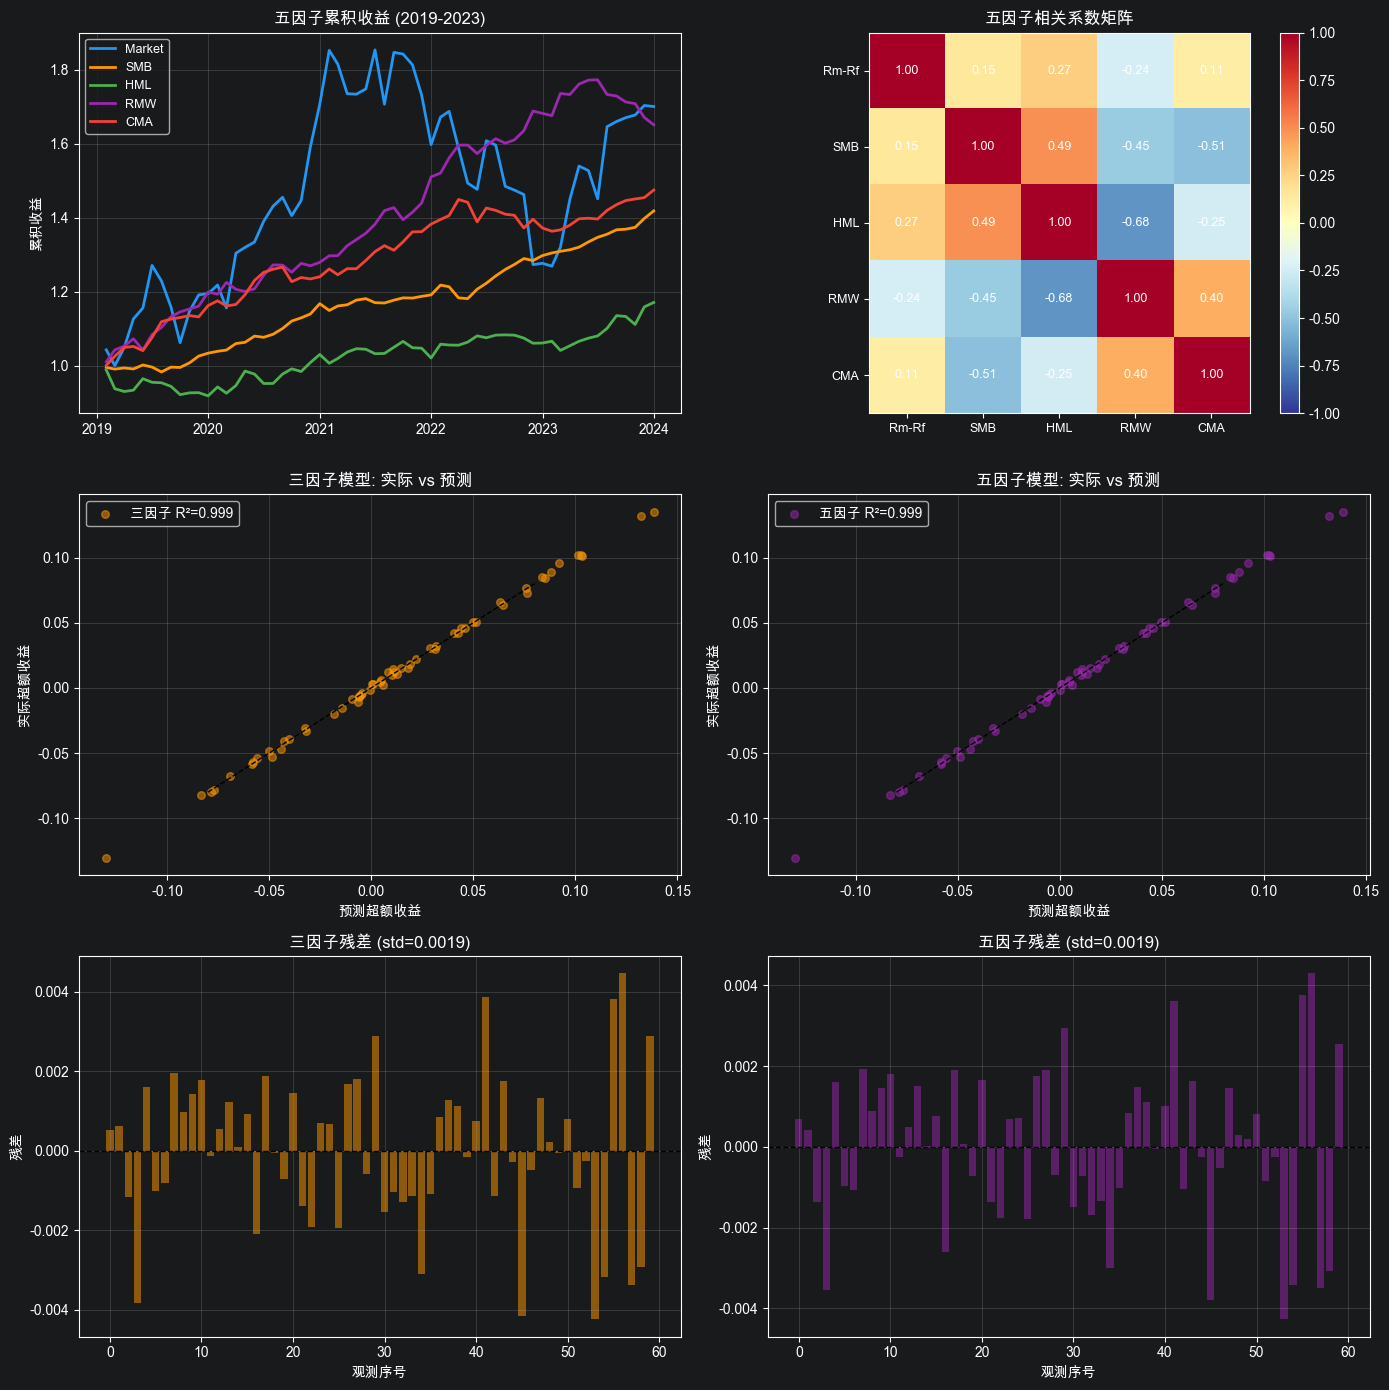

图表已保存: five_factor_analysis.png


In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# ---- 1. 五个因子的累积收益 ----
ax1 = axes[0, 0]
for col, label, color in [
    ('Rm_Rf', 'Market', '#2196F3'),
    ('SMB', 'SMB', '#FF9800'),
    ('HML', 'HML', '#4CAF50'),
    ('RMW', 'RMW', '#9C27B0'),
    ('CMA', 'CMA', '#F44336')
]:
    cum = (1 + factors_df[col]).cumprod()
    ax1.plot(factors_df['date'], cum, label=label, linewidth=2, color=color)
ax1.set_title('五因子累积收益 (2019-2023)', fontsize=12)
ax1.set_ylabel('累积收益')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# ---- 2. 因子相关性热力图 ----
ax2 = axes[0, 1]
corr_matrix = factors_df[['Rm_Rf', 'SMB', 'HML', 'RMW', 'CMA']].corr()
im = ax2.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)
labels = ['Rm-Rf', 'SMB', 'HML', 'RMW', 'CMA']
ax2.set_xticks(range(5))
ax2.set_yticks(range(5))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_title('五因子相关系数矩阵', fontsize=12)
for i in range(5):
    for j in range(5):
        ax2.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax2)

# ---- 3. 三因子 vs 五因子：预测值对比 ----
ax3 = axes[1, 0]
pred_3f = model_3f.predict(X_3f)
pred_5f = model_5f.predict(X_5f)
ax3.scatter(pred_3f, y, alpha=0.5, s=30, label=f'三因子 R²={model_3f.rsquared:.3f}', color='#FF9800')
ax3.plot([-0.08, 0.08], [-0.08, 0.08], 'k--', linewidth=1)
ax3.set_xlabel('预测超额收益')
ax3.set_ylabel('实际超额收益')
ax3.set_title('三因子模型: 实际 vs 预测', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.scatter(pred_5f, y, alpha=0.5, s=30, label=f'五因子 R²={model_5f.rsquared:.3f}', color='#9C27B0')
ax4.plot([-0.08, 0.08], [-0.08, 0.08], 'k--', linewidth=1)
ax4.set_xlabel('预测超额收益')
ax4.set_ylabel('实际超额收益')
ax4.set_title('五因子模型: 实际 vs 预测', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

# ---- 4. 残差对比 ----
ax5 = axes[2, 0]
ax5.bar(range(len(model_3f.resid)), model_3f.resid, alpha=0.5, color='#FF9800', label='三因子残差')
ax5.axhline(y=0, color='k', linestyle='--', linewidth=1)
ax5.set_xlabel('观测序号')
ax5.set_ylabel('残差')
ax5.set_title(f'三因子残差 (std={model_3f.resid.std():.4f})', fontsize=12)
ax5.grid(True, alpha=0.3)

ax6 = axes[2, 1]
ax6.bar(range(len(model_5f.resid)), model_5f.resid, alpha=0.5, color='#9C27B0', label='五因子残差')
ax6.axhline(y=0, color='k', linestyle='--', linewidth=1)
ax6.set_xlabel('观测序号')
ax6.set_ylabel('残差')
ax6.set_title(f'五因子残差 (std={model_5f.resid.std():.4f})', fontsize=12)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('five_factor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存: five_factor_analysis.png")

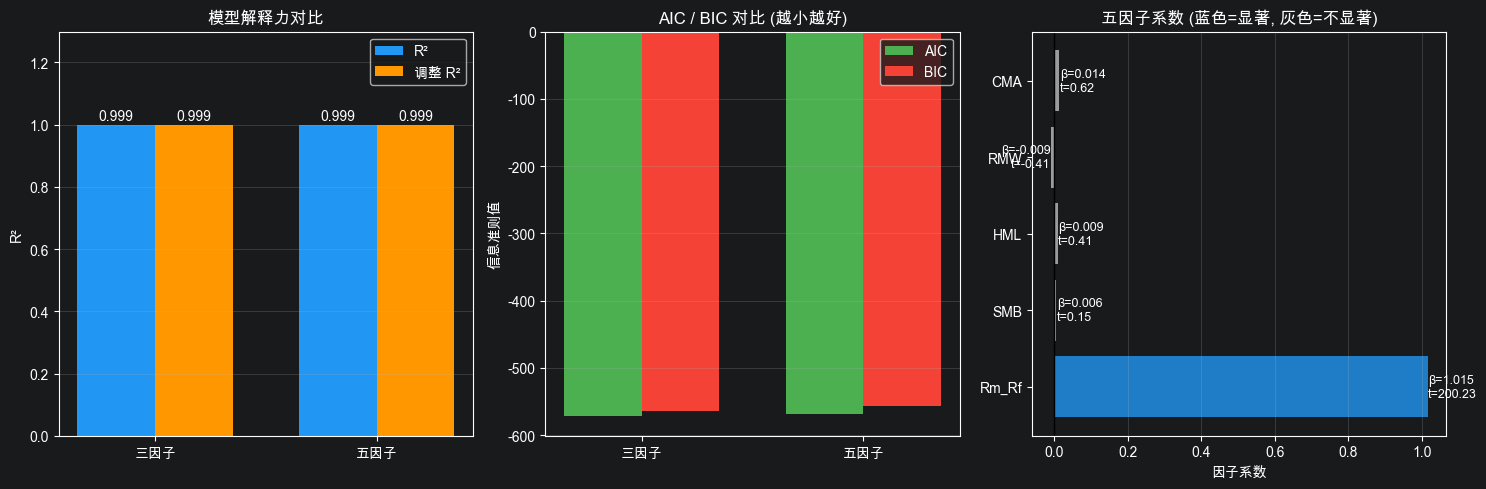

图表已保存: five_factor_comparison.png


In [14]:
# === 模型对比柱状图 ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. R² 对比
ax1 = axes[0]
models = ['三因子', '五因子']
r2_vals = [model_3f.rsquared, model_5f.rsquared]
adj_r2_vals = [model_3f.rsquared_adj, model_5f.rsquared_adj]
x = np.arange(len(models))
width = 0.35
bars1 = ax1.bar(x - width/2, r2_vals, width, label='R²', color='#2196F3')
bars2 = ax1.bar(x + width/2, adj_r2_vals, width, label='调整 R²', color='#FF9800')
ax1.set_ylabel('R²')
ax1.set_title('模型解释力对比', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.set_ylim(0, max(r2_vals) * 1.3)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# 2. AIC/BIC 对比
ax2 = axes[1]
aic_vals = [model_3f.aic, model_5f.aic]
bic_vals = [model_3f.bic, model_5f.bic]
bars1 = ax2.bar(x - width/2, aic_vals, width, label='AIC', color='#4CAF50')
bars2 = ax2.bar(x + width/2, bic_vals, width, label='BIC', color='#F44336')
ax2.set_ylabel('信息准则值')
ax2.set_title('AIC / BIC 对比 (越小越好)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. 各因子系数及显著性
ax3 = axes[2]
factor_names = ['Rm_Rf', 'SMB', 'HML', 'RMW', 'CMA']
coeffs = [model_5f.params[f] for f in factor_names]
t_vals = [model_5f.tvalues[f] for f in factor_names]
colors = ['#2196F3' if abs(t) >= 2 else '#BDBDBD' for t in t_vals]
bars = ax3.barh(factor_names, coeffs, color=colors, alpha=0.8)
ax3.axvline(x=0, color='k', linewidth=1)
ax3.set_xlabel('因子系数')
ax3.set_title('五因子系数 (蓝色=显著, 灰色=不显著)', fontsize=12)
for i, (c, t) in enumerate(zip(coeffs, t_vals)):
    ax3.text(c + 0.001 if c >= 0 else c - 0.001, i,
            f'β={c:.3f}\nt={t:.2f}', va='center',
            ha='left' if c >= 0 else 'right', fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('five_factor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存: five_factor_comparison.png")

## 五、不同组合的因子暴露分析

让我们看看不同类型的投资组合在五因子上的暴露有何差异。

In [15]:
def five_factor_regression(df, factors_df, rf_monthly, portfolio_name='Portfolio'):
    """
    对任意投资组合做五因子回归，返回结果字典
    """
    # 构建组合收益
    port_ret = df.groupby('date')['return'].mean().reset_index()
    port_ret.columns = ['date', 'R_portfolio']
    
    reg = port_ret.merge(factors_df, on='date')
    reg['R_p_Rf'] = reg['R_portfolio'] - rf_monthly
    
    X = reg[['Rm_Rf', 'SMB', 'HML', 'RMW', 'CMA']]
    X = sm.add_constant(X)
    y = reg['R_p_Rf']
    
    model = sm.OLS(y, X).fit()
    
    return {
        'name': portfolio_name,
        'alpha': model.params['const'],
        'beta': model.params['Rm_Rf'],
        'smb': model.params['SMB'],
        'hml': model.params['HML'],
        'rmw': model.params['RMW'],
        'cma': model.params['CMA'],
        'r2': model.rsquared,
        'adj_r2': model.rsquared_adj
    }

# 构建不同类型的组合
portfolios = {}

# 1. 小市值组合（市值 < 25% 分位数）
cap_q25 = df.groupby('stock_id')['market_cap'].first().quantile(0.25)
small_cap_stocks = df.groupby('stock_id')['market_cap'].first()
small_cap_ids = small_cap_stocks[small_cap_stocks <= cap_q25].index
small_cap_df = df[df['stock_id'].isin(small_cap_ids)]
portfolios['小市值'] = five_factor_regression(small_cap_df, factors_df, rf_monthly, '小市值')

# 2. 大市值组合（市值 > 75% 分位数）
cap_q75 = small_cap_stocks.quantile(0.75)
big_cap_ids = small_cap_stocks[small_cap_stocks >= cap_q75].index
big_cap_df = df[df['stock_id'].isin(big_cap_ids)]
portfolios['大市值'] = five_factor_regression(big_cap_df, factors_df, rf_monthly, '大市值')

# 3. 高盈利组合（盈利能力 > 75% 分位数）
prof_q75 = df.groupby('stock_id')['profitability'].first().quantile(0.75)
prof_stocks = df.groupby('stock_id')['profitability'].first()
high_prof_ids = prof_stocks[prof_stocks >= prof_q75].index
high_prof_df = df[df['stock_id'].isin(high_prof_ids)]
portfolios['高盈利'] = five_factor_regression(high_prof_df, factors_df, rf_monthly, '高盈利')

# 4. 保守投资组合（投资率 < 25% 分位数）
inv_q25 = df.groupby('stock_id')['investment_rate'].first().quantile(0.25)
inv_stocks = df.groupby('stock_id')['investment_rate'].first()
cons_ids = inv_stocks[inv_stocks <= inv_q25].index
cons_df = df[df['stock_id'].isin(cons_ids)]
portfolios['保守投资'] = five_factor_regression(cons_df, factors_df, rf_monthly, '保守投资')

# 展示结果
results_df = pd.DataFrame(portfolios).T
results_df = results_df[['name', 'alpha', 'beta', 'smb', 'hml', 'rmw', 'cma', 'r2', 'adj_r2']]
results_df.columns = ['组合', 'Alpha', 'Beta', 'SMB', 'HML', 'RMW', 'CMA', 'R²', '调整R²']

print("不同组合的五因子暴露:")
print("=" * 80)
print(results_df.to_string(float_format=lambda x: f'{x:.4f}'))

不同组合的五因子暴露:
        组合   Alpha   Beta     SMB    HML     RMW     CMA     R²   调整R²
小市值    小市值  0.0069 1.0313 -0.0347 0.0599  0.0552 -0.0402 0.9954 0.9949
大市值    大市值 -0.0001 1.0214 -0.3574 0.0829 -0.0369 -0.0182 0.9972 0.9969
高盈利    高盈利  0.0073 1.0376 -0.0044 0.0450  0.1154  0.0282 0.9957 0.9953
保守投资  保守投资  0.0052 1.0122 -0.0020 0.0226 -0.0340  0.1219 0.9943 0.9938


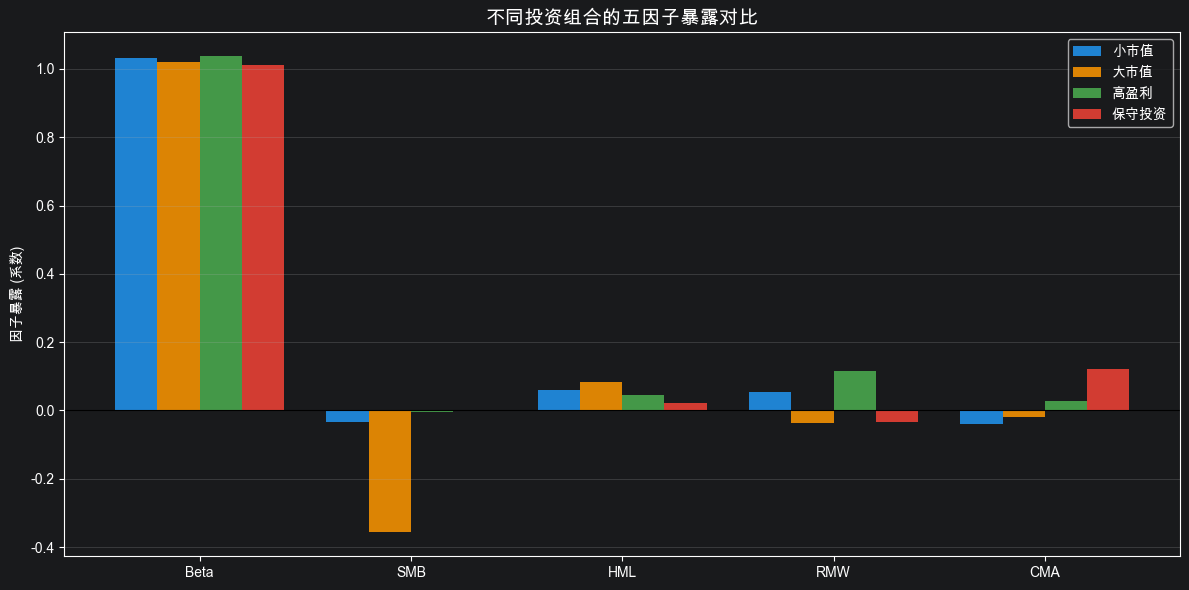

图表已保存: portfolio_factor_exposure.png


In [16]:
# 可视化不同组合的因子暴露
fig, ax = plt.subplots(figsize=(12, 6))

factor_cols = ['Beta', 'SMB', 'HML', 'RMW', 'CMA']
portfolio_names = results_df['组合'].tolist()
x = np.arange(len(factor_cols))
width = 0.2
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']

for i, name in enumerate(portfolio_names):
    vals = results_df.loc[name, factor_cols].values.astype(float)
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(factor_cols)
ax.set_ylabel('因子暴露 (系数)')
ax.set_title('不同投资组合的五因子暴露对比', fontsize=14)
ax.legend()
ax.axhline(y=0, color='k', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('portfolio_factor_exposure.png', dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存: portfolio_factor_exposure.png")

## 六、因子解读：不做机械调包

### 6.1 回归系数的经济含义

| 系数 | 含义 | 举例 |
|------|------|------|
| $\beta > 1$ | 组合比市场波动更大 | 激进型基金 |
| $s > 0$ | 组合偏向小市值 | 小盘股基金 |
| $h > 0$ | 组合偏向价值股 | 价值投资策略 |
| $r > 0$ | 组合偏向高盈利 | 质量投资策略 |
| $c > 0$ | 组合偏向保守投资 | 低资本支出公司 |
| $\alpha > 0$ | 存在超额收益（需检验显著性） | 选股能力 |

### 6.2 五因子模型的投资启示

1. **质量投资（Quality Investing）**：通过 RMW 因子，我们可以识别出盈利能力强的公司，这类公司长期表现优异
2. **保守投资溢价**：CMA 因子告诉我们，激进扩张的公司不一定能带来更高回报
3. **因子投资组合构建**：可以根据因子暴露来设计投资策略，例如做多高盈利 + 做空低盈利

### 6.3 五因子模型的争议

- **HML 被削弱**：加入 RMW 和 CMA 后，HML 的解释力下降，Fama 认为这是因为 RMW 和 CMA 捕获了 HML 中部分信息
- **因子正交性**：五因子之间可能存在相关性，需要关注多重共线性问题
- **数据挖掘风险**：因子数量越多，越需要警惕数据挖掘（data snooping）

## 七、小结

### 核心要点

1. **五因子模型**在三因子基础上增加了 **RMW（盈利因子）** 和 **CMA（投资因子）**
2. **RMW** 捕获盈利质量溢价：高盈利公司有更强的抗风险能力
3. **CMA** 捕获投资风格溢价：保守投资公司现金流更稳定
4. 五因子模型的**调整 R² 高于三因子**，说明新增因子有增量解释力
5. 理解每个因子背后的**经济学故事**，比会调包更重要

### 关键公式

$$R_i - R_f = \alpha + \beta(R_m - R_f) + s \cdot SMB + h \cdot HML + r \cdot RMW + c \cdot CMA + \epsilon$$

### 因子构建速查

| 因子 | 分组变量 | 做多 | 做空 | 分位数 |
|------|----------|------|------|--------|
| SMB | 市值 | 小市值 | 大市值 | 中位数 |
| HML | B/M 比 | 高 B/M | 低 B/M | 30%/70% |
| RMW | 盈利能力 | 高盈利 | 低盈利 | 30%/70% |
| CMA | 投资率 | 低投资 | 高投资 | 30%/70% |

### 验收标准 Checklist

- [x] 能解释为什么需要五因子（三因子的局限性）
- [x] 理解 RMW 和 CMA 的经济学故事
- [x] 能手工构建 RMW 和 CMA 因子
- [x] 能对比三因子和五因子的调整 R²
- [x] 不做机械调包，能解释每个系数的含义
- [x] 理解嵌套模型 F 检验的含义

### 下一步预告

序号 16：**BS 公式与 Greeks** — 从因子模型转向期权定价，学习 Black-Scholes 公式的推导和 Greeks 的计算。